In [1]:
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

# On masque les alertes techniques inutiles pour le rendu final
warnings.filterwarnings('ignore')

# Chargement du fichier
print("Chargement en cours...")
df_final = pd.read_csv('dataset_final_backup.csv', low_memory=False)

print(f"Chargement réussi : {len(df_final)} lignes.")

Chargement en cours...
Chargement réussi : 5621008 lignes.


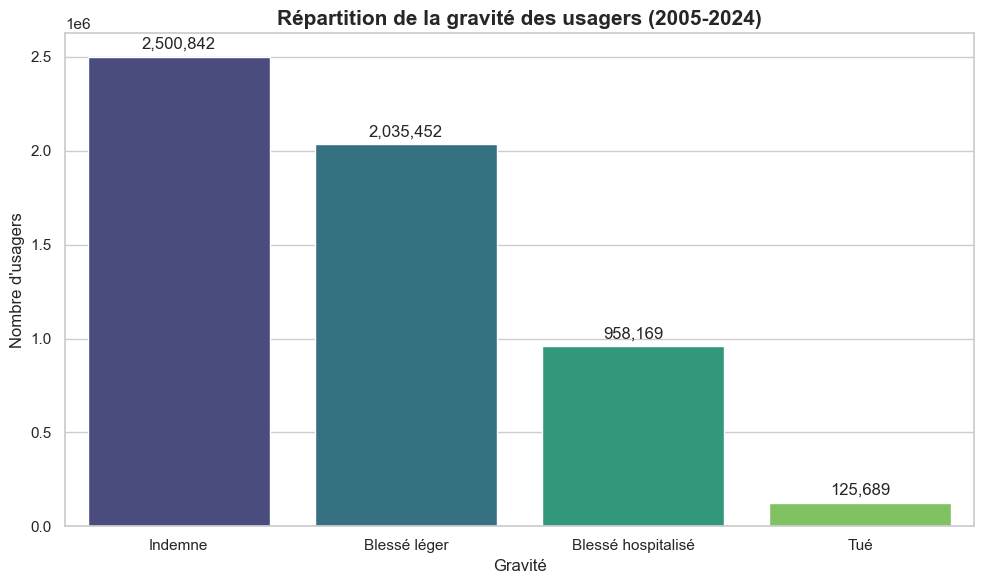

In [19]:
# 1. Préparation des données
# On compte le nombre d'usagers par catégorie de gravité
data_grav = df_final['grav_label'].value_counts().reset_index()
data_grav.columns = ['Gravité', 'Nombre d\'usagers']

# 2. Création du graphique
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Barplot pour visualiser les effectifs
ax = sns.barplot(data=data_grav, x='Gravité', y='Nombre d\'usagers', palette='viridis')

# Ajout des labels et titre
plt.title('Répartition de la gravité des usagers (2005-2024)', fontsize=15, fontweight='bold')
plt.xlabel('Gravité', fontsize=12)
plt.ylabel('Nombre d\'usagers', fontsize=12)

# Ajout des valeurs au-dessus des barres pour plus de précision
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

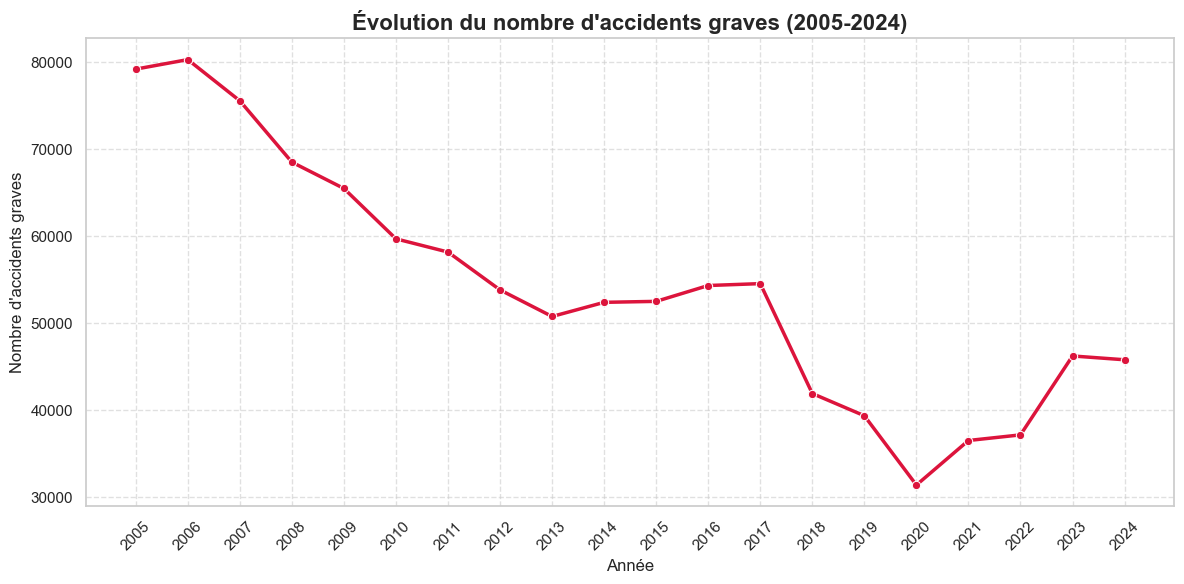

In [3]:
# 1. Préparation des données pour le Graphique 2
# Filtrage : On ne garde que les usagers avec une gravité de 2 (Tué) ou 3 (Blessé hospitalisé)
data_clean = df_final[df_final['grav'].isin([2, 3])].copy()

# On groupe par l'année 'an' (maintenant propre et complète)
evolution = data_clean.groupby('an').size().reset_index(name='nb_accidents')

# 2. Création du graphique professionnel
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid") # Style épuré pour le jury

# Tracé de la ligne avec marqueurs pour plus de lisibilité
sns.lineplot(data=evolution, x='an', y='nb_accidents', marker='o', linewidth=2.5, color='crimson')

# 3. Personnalisation esthétique
plt.title('Évolution du nombre d\'accidents graves (2005-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Année', fontsize=12)
plt.ylabel('Nombre d\'accidents graves', fontsize=12)

# Ajustement de l'axe X pour afficher chaque année
plt.xticks(evolution['an'], rotation=45) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

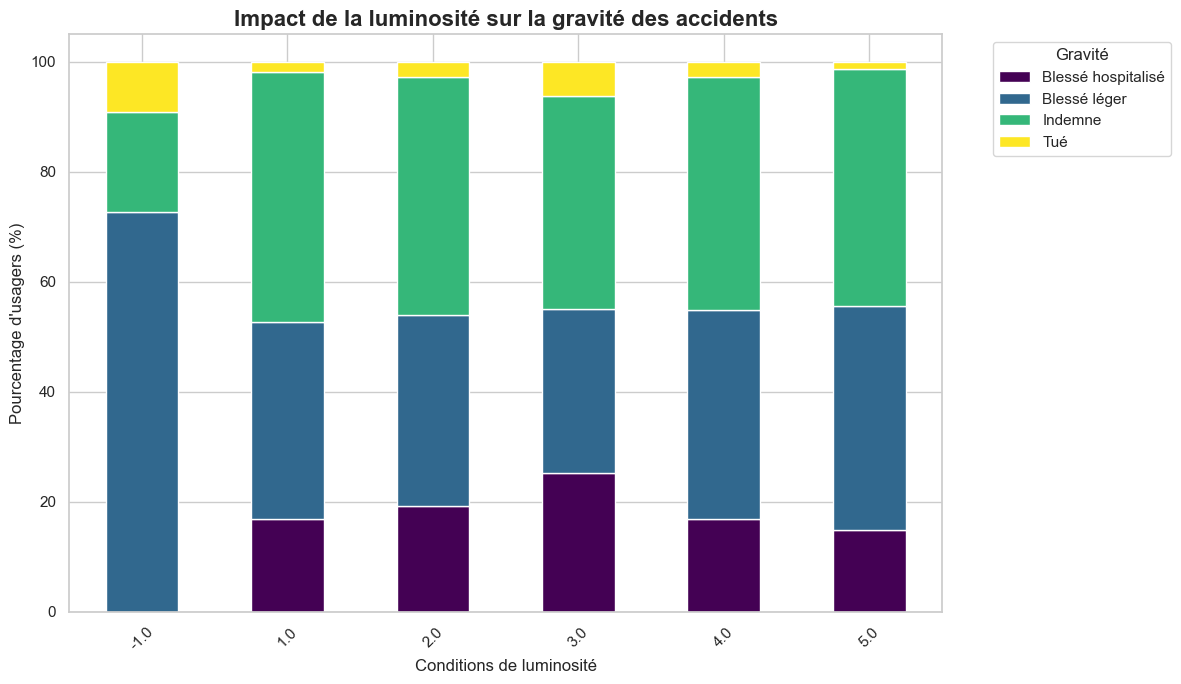

In [4]:
# 1. Préparation : On prépare les données pour comparer luminosité vs gravité
# On crée un tableau croisé (pivot) pour avoir le pourcentage de chaque gravité par condition de lumière
data_lum = df_final.groupby(['lum', 'grav_label']).size().unstack(fill_value=0)
data_lum_pct = data_lum.div(data_lum.sum(axis=1), axis=0) * 100

# 2. Création du graphique
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Barplot empilé pour comparer les proportions
data_lum_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

# Personnalisation
plt.title('Impact de la luminosité sur la gravité des accidents', fontsize=16, fontweight='bold')
plt.xlabel('Conditions de luminosité', fontsize=12)
plt.ylabel('Pourcentage d\'usagers (%)', fontsize=12)
plt.legend(title='Gravité', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

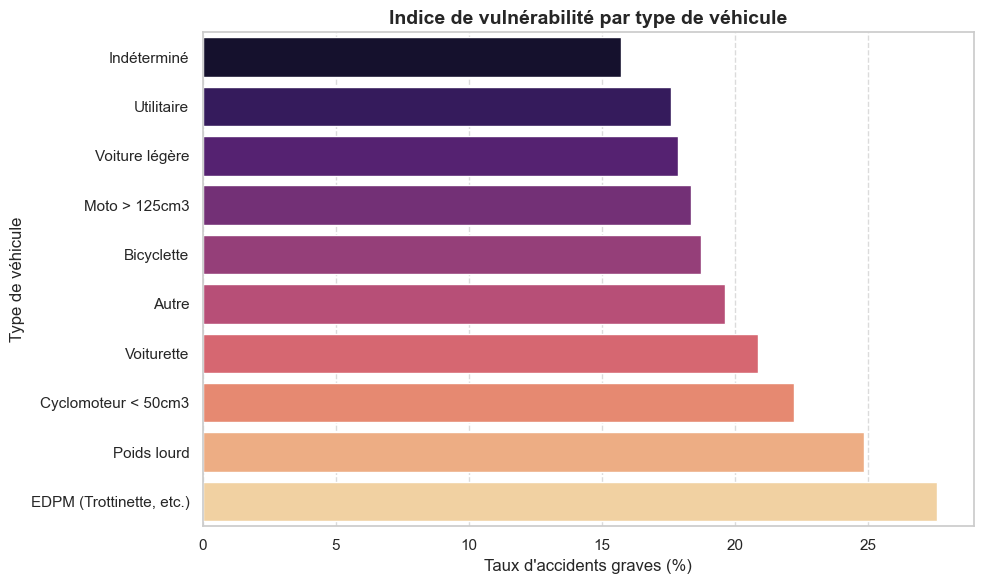

In [6]:
# 1. Dictionnaire de référence (Index des véhicules)
dict_catv = {
    0: "Indéterminé",
    1: "Bicyclette",
    2: "Cyclomoteur < 50cm3",
    3: "Voiturette",
    7: "Moto > 125cm3",
    10: "Voiture légère",
    13: "Utilitaire",
    14: "Poids lourd",
    33: "EDPM (Trottinette, etc.)"
}

# 2. Préparation des données avec le mapping
# On crée la colonne avec les noms lisibles
df_final['catv_label'] = df_final['catv'].map(dict_catv).fillna("Autre")

# Calcul de la vulnérabilité
df_final['est_grave'] = df_final['grav'].isin([2, 3]).astype(int)
vuln = df_final.groupby('catv_label')['est_grave'].mean() * 100 
vuln = vuln.sort_values(ascending=True) # Trié pour une meilleure lecture

# 3. Graphique avec index intégré
plt.figure(figsize=(10, 6))
sns.barplot(x=vuln.values, y=vuln.index, palette="magma", orient='h')

plt.title('Indice de vulnérabilité par type de véhicule', fontsize=14, fontweight='bold')
plt.xlabel('Taux d\'accidents graves (%)', fontsize=12)
plt.ylabel('Type de véhicule', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

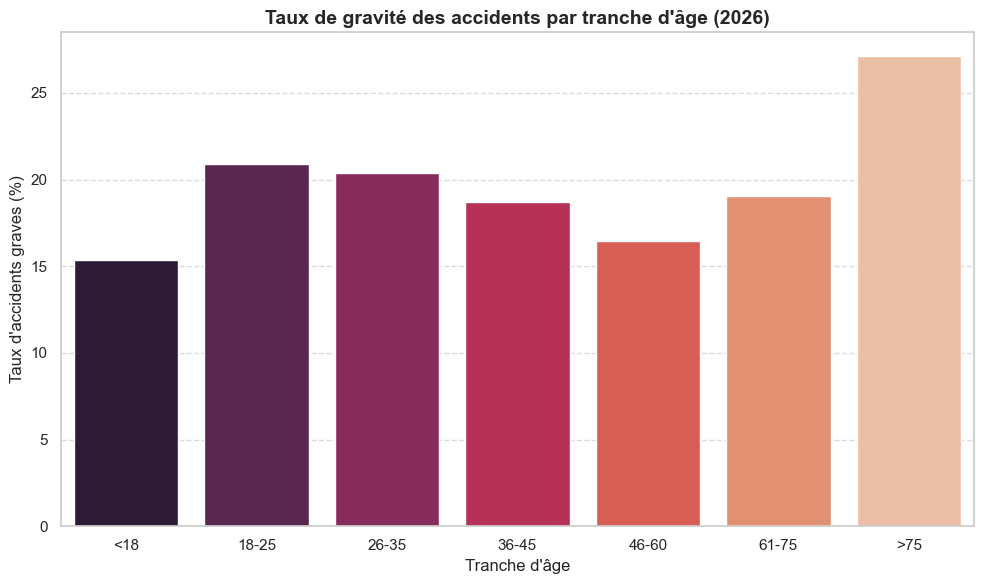

In [9]:
# 1. Calcul de l'âge à partir de l'année de naissance
# On prend 2026 (l'année actuelle) moins l'année de naissance
# errors='coerce' transforme les valeurs non numériques (si elles existent) en NaN
df_final['an_nais'] = pd.to_numeric(df_final['an_nais'], errors='coerce')
df_final['age'] = 2026 - df_final['an_nais']

# On supprime les lignes où l'âge est incohérent (ex: âgé de plus de 110 ans ou naissance future)
df_final = df_final[(df_final['age'] >= 0) & (df_final['age'] <= 110)]

# 2. Création des tranches d'âge
bins = [0, 18, 25, 35, 45, 60, 75, 110]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '61-75', '>75']
df_final['tranche_age'] = pd.cut(df_final['age'], bins=bins, labels=labels)

# 3. Calcul du taux de gravité
df_age = df_final.groupby('tranche_age', observed=True)['est_grave'].mean() * 100

# 4. Création du graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=df_age.index, y=df_age.values, palette="rocket")

plt.title('Taux de gravité des accidents par tranche d\'âge (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Tranche d\'âge', fontsize=12)
plt.ylabel('Taux d\'accidents graves (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
plt.show()

In [2]:
import pandas as pd

# 1. Charger le fichier (assurez-vous que le chemin est correct)
df = pd.read_csv('dataset_final_backup.csv')

# 2. Afficher le type de données de la colonne
print("Type de la colonne 'départements' :")
print(df['dep'].dtype)
print("-" * 30)

# 3. Voir toutes les valeurs uniques présentes dans la colonne
# Cela vous permettra de repérer immédiatement les "2A", "2B" ou valeurs étranges
print("Valeurs uniques dans la colonne :")
print(df['dep'].unique())
print("-" * 30)

# 4. Compter les occurrences (pour voir combien de fois chaque valeur apparaît)
print("Nombre d'occurrences par valeur :")
print(df['dep'].value_counts())

C:\Users\Kufte\AppData\Local\Temp\ipykernel_13144\1789323079.py:4: DtypeWarning: Columns (8,12,16,20,27,29,33,34,51,53,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataset_final_backup.csv')


Type de la colonne 'départements' :
object
------------------------------
Valeurs uniques dans la colonne :
[590 620 800 20 600 570 760 270 350 220 290 560 140 500 940 10 610 440 490
 530 720 850 330 870 380 240 910 400 470 640 860 160 170 790 190 230 310
 90 120 320 460 650 810 690 820 70 260 420 730 740 630 30 150 430 540 550
 880 670 680 510 80 100 520 450 890 210 580 710 250 390 40 700 900 130 50
 60 830 840 340 110 300 480 660 201 202 780 950 770 180 280 360 370 410
 920 930 750 972 971 973 974 976 91 77 76 68 64 62 59 56 54 51 48 35 31 26
 22 17 13 6 75 94 93 92 66 65 49 44 38 84 3 72 16 7 28 37 33 988 88 55 1
 69 78 '91' '89' '87' '84' '30' '83' '78' '77' '74' '69' '67' '66' '64'
 '63' '60' '58' '56' '54' '51' '976' '971' '2A' '34' '06' '71' '57' '73'
 '38' '35' '62' '33' '59' '94' '988' '95' '44' '37' '29' '27' '13' '12'
 '03' '75' '93' '92' '08' '31' '86' '19' '76' '65' '61' '49' '42' '02'
 '43' '53' '21' '40' '52' '88' '17' '68' '974' '45' '39' '85' '50' '14'
 '80' '28' '18' 

In [3]:
import pandas as pd

# 1. On transforme tout en chaîne de caractères pour pouvoir manipuler les textes
df['dep'] = df['dep'].astype(str)

# 2. On nettoie les guillemets et les espaces parasites
df['dep'] = df['dep'].str.replace("'", "").str.strip()

# 3. Remplacement manuel des cas spéciaux (Corse et DOM)
# On s'assure de transformer les formats textuels en codes numériques cohérents
mapping = {
    '2A': '201', '2B': '202',
    '971': '971', '972': '972', '973': '973', '974': '974', '976': '976'
}
df['dep'] = df['dep'].replace(mapping)

# 4. Conversion finale en nombre entier
# 'coerce' va transformer tout ce qu'il ne comprend pas (ex: "nan") en NaN
df['dep'] = pd.to_numeric(df['dep'], errors='coerce')

# 5. On remplit les erreurs (NaN) par 0
df['dep'] = df['dep'].fillna(0).astype(int)

# Vérification du résultat
print("Nombre de valeurs uniques après nettoyage :", df['dep'].nunique())
print("Exemple de valeurs :", df['dep'].unique()[:20])

# 6. Sauvegarde pour Power BI
df.to_csv('dataset_propre.csv', index=False)
print("\nFichier 'dataset_propre.csv' généré avec succès !")

Nombre de valeurs uniques après nettoyage : 193
Exemple de valeurs : [590 620 800  20 600 570 760 270 350 220 290 560 140 500 940  10 610 440
 490 530]

Fichier 'dataset_propre.csv' généré avec succès !
